In [5]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Load Dataset
df = pd.read_excel("Cleaned Dataset.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
#Data structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [5]:
#View column names
print(df.columns)

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')


In [6]:
#Check Dataset Size
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1200
Columns: 14


In [7]:
#Descriptive statistics
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [8]:
#Calculate Mean
mean_quantity = df["Quantity"].mean()

print("Average Quantity:", mean_quantity)

Average Quantity: 2.9458333333333333


In [9]:
#Calculate Median
median_quantity = df["Quantity"].median()

print("Median Quantity:", median_quantity)

Median Quantity: 3.0


In [10]:
#Calculate Count
count_quantity = df["Quantity"].count()

print("Count:", count_quantity)

Count: 1200


In [11]:
#Create a Charts Folder
import os

os.makedirs("charts", exist_ok=True)

In [12]:
#Analyze Product Distribution
product_count = df["Product"].value_counts()

print(product_count)

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


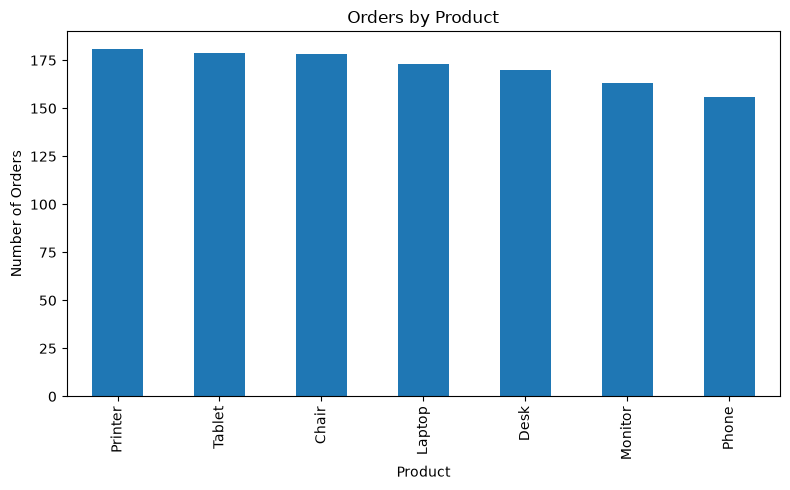

In [13]:
#Visualize Product Distribution
plt.figure(figsize=(8,5))
product_count.plot(kind="bar")

plt.title("Orders by Product")
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig("charts/product_distribution.png")

plt.show()

In [14]:
#Analyze Payment Methods
payment_count = df["PaymentMethod"].value_counts()

print(payment_count)

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


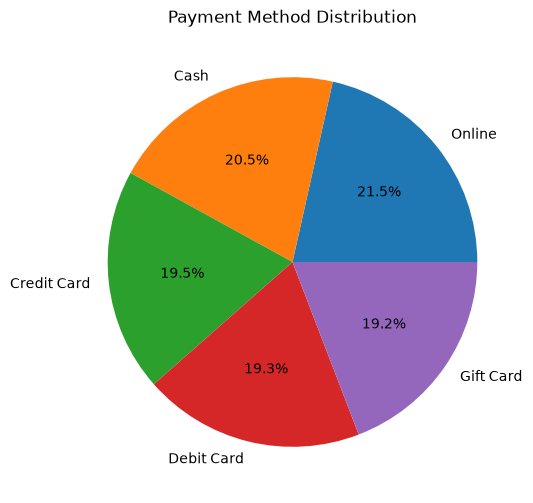

In [15]:
#Visualize Payment Methods
plt.figure(figsize=(8,6))
payment_count.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")
plt.ylabel("")

plt.savefig("charts/payment_distribution.png")

plt.show()

In [16]:
#Analyze Referral Sources
referrals = df["ReferralSource"].value_counts()

print(referrals)

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


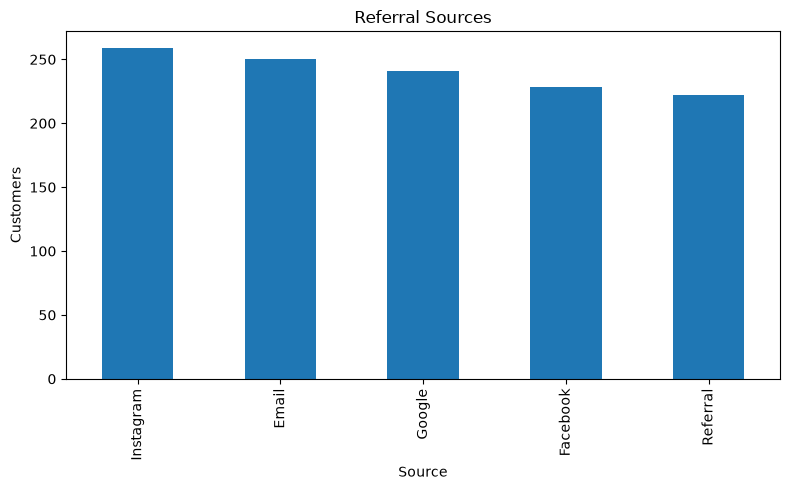

In [17]:
#Visualize Referral Sources
plt.figure(figsize=(8,5))
referrals.plot(kind="bar")

plt.title("Referral Sources")
plt.xlabel("Source")
plt.ylabel("Customers")

plt.tight_layout()

plt.savefig("charts/referral_sources.png")

plt.show()

In [18]:
#Revenue Analysis
avg_revenue = df.groupby("Product")["TotalPrice"].mean()

print(avg_revenue)

Product
Chair      1098.989382
Desk        985.058412
Laptop     1110.558150
Monitor    1077.616012
Phone       972.579423
Printer    1080.732652
Tablet     1042.284637
Name: TotalPrice, dtype: float64


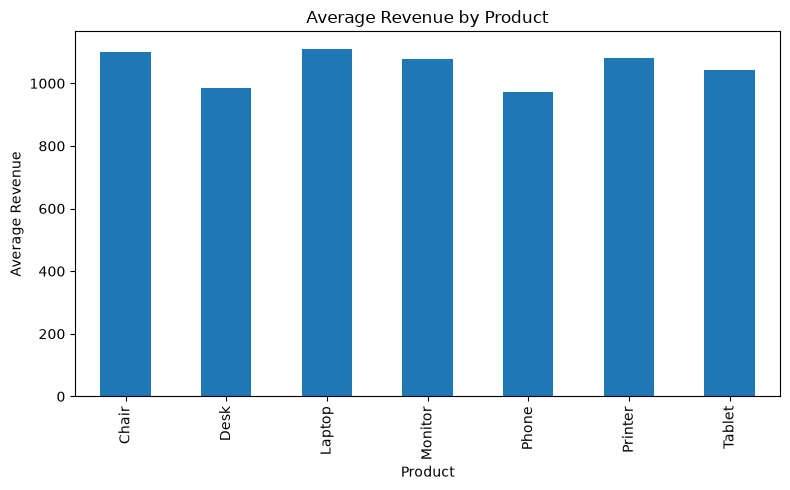

In [19]:
#Revenue Visualization
plt.figure(figsize=(8,5))
avg_revenue.plot(kind="bar")

plt.title("Average Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Average Revenue")

plt.tight_layout()

plt.savefig("charts/revenue_by_product.png")

plt.show()

In [20]:
#Identify Outliers
Q1 = df["TotalPrice"].quantile(0.25)

Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

In [21]:
#Calculate Outlier Boundaries
lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

In [22]:
#Extract Outliers
outliers = df[
    (df["TotalPrice"] < lower_bound) |
    (df["TotalPrice"] > upper_bound)
]

print(outliers)

        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
107   ORD200107 2023-03-27     C16775  Printer         5     670.75   
326   ORD200326 2024-07-01     C65986   Laptop         5     670.48   
328   ORD200328 2023-02-28     C18404   Tablet         5     674.04   
469   ORD200469 2023-11-26     C13877    Chair         5     676.98   
632   ORD200632 2023-05-02     C67260   Laptop         5     678.16   
789   ORD200789 2023-08-17     C57276   Tablet         5     691.28   
1065  ORD201065 2023-10-30     C47778  Printer         5     666.80   
1122  ORD201122 2023-06-07     C38840  Monitor         5     678.19   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
107      848 Main St     Gift Card     Shipped    TRK34392124            8   
326      273 Main St     Gift Card    Returned    TRK98353867            5   
328      546 Main St        Online   Cancelled    TRK89401624            7   
469      893 Main St          Cash   Cancelled  

In [23]:
#Count Outliers
print("Number of Outliers:", len(outliers))

Number of Outliers: 8


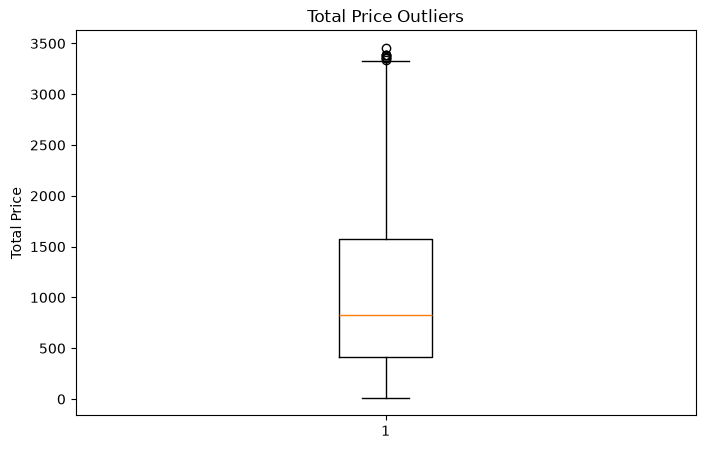

In [24]:
#Visualize Outliers
plt.figure(figsize=(8,5))

plt.boxplot(df["TotalPrice"])

plt.title("Total Price Outliers")
plt.ylabel("Total Price")

plt.savefig("charts/outliers_boxplot.png")

plt.show()

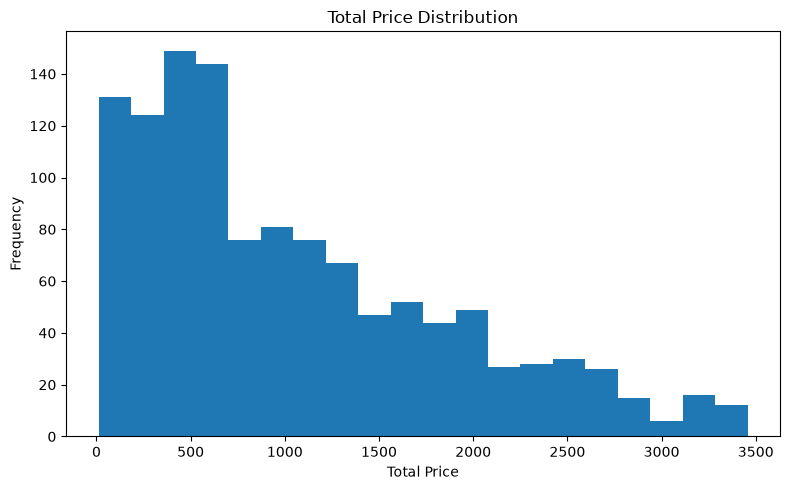

In [25]:
#Histogram of Total Price
plt.figure(figsize=(8,5))

plt.hist(df["TotalPrice"], bins=20)

plt.title("Total Price Distribution")
plt.xlabel("Total Price")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("charts/total_price_distribution.png")

plt.show()

In [26]:
#Correlation Analysis
correlation = df[
    ["Quantity",
     "UnitPrice",
     "TotalPrice"]
].corr()

print(correlation)

            Quantity  UnitPrice  TotalPrice
Quantity    1.000000   0.014553    0.615251
UnitPrice   0.014553   1.000000    0.717081
TotalPrice  0.615251   0.717081    1.000000


In [27]:
#Verify Saved Files
import os

print(os.listdir("charts"))

['outliers_boxplot.png', 'payment_distribution.png', 'product_distribution.png', 'referral_sources.png', 'revenue_by_product.png', 'total_price_distribution.png']
